In [30]:
import sleap
import numpy as np

# This prevents TensorFlow from allocating all the GPU memory, which leads to issues on
# some GPUs/platforms:
# sleap.disable_preallocation()

# This would hide GPUs from the TensorFlow altogether:
# sleap.use_cpu_onl
# Print some info:
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: True
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: True


In [2]:
c3_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/predictions/c3_predictions.slp.250120_125305.predictions.slp'
c3_labels = sleap.load_file(c3_labels_path)

In [3]:
c3_labels.labeled_frames[0]

LabeledFrame(video=MediaVideo('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4'), frame_idx=0, instances=17)

In [14]:
c3_labels.labeled_frames[0].instances

[PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170, 174, 1), backend=MediaVideo), frame_idx=0, points=[tb1_node: (106.4, 28.5, 1.00)], score=0.91, track=Track(spawned_on=0, name='track_0'), tracking_score=0.00),
 PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170, 174, 1), backend=MediaVideo), frame_idx=0, points=[tb1_node: (80.1, 30.7, 1.00)], score=0.94, track=Track(spawned_on=0, name='track_1'), tracking_score=0.00),
 PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170, 174, 1), backend=MediaVideo), frame_idx=0, points=[tb1_node: (60.7, 36.8, 1.00)], score=0.90, track=Track(spawned_on=0, name='track_2'), tracking_score=0.00),
 PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170

In [24]:
c3_labels.labeled_frames[0].instances[0].points[0].x

106.39509582519531

In [15]:
missing_point_cnt = 0
missing_point_frame_idx = []
missing_track_cnt = 0
for lbf in c3_labels.labeled_frames:
    if len(lbf.instances) != 17:
        missing_point_cnt += 1
        missing_point_frame_idx.append(lbf.frame_idx)
    for instance in lbf.instances:
        try:
            assert instance.track is not None
        except:
            missing_track_cnt += 1
print(f"missing_point_cnt: {missing_point_cnt}")
print(f"missing_track_cnt: {missing_track_cnt}")

missing_point_cnt: 81
missing_track_cnt: 0


In [17]:
c3_labels.labeled_frames[missing_point_frame_idx[0]].instances

[PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170, 174, 1), backend=MediaVideo), frame_idx=143, points=[tb1_node: (80.4, 40.4, 1.00)], score=0.94, track=Track(spawned_on=0, name='track_1'), tracking_score=-3.83),
 PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170, 174, 1), backend=MediaVideo), frame_idx=143, points=[tb1_node: (104.5, 46.4, 1.00)], score=0.71, track=Track(spawned_on=0, name='track_0'), tracking_score=-4.49),
 PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170, 174, 1), backend=MediaVideo), frame_idx=143, points=[tb1_node: (64.2, 48.2, 1.00)], score=0.91, track=Track(spawned_on=0, name='track_2'), tracking_score=-0.23),
 PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=

In [19]:
c3_labels.skeletons

[Skeleton(name='TB1', description='None', nodes=['tb1_node'], edges=[], symmetries=[])]

## interpolate missing point position

In [26]:
frame_cnt = len(c3_labels.labeled_frames)
instance_cnt = len(c3_labels.labeled_frames[0].instances)
print(frame_cnt, instance_cnt)
all_tracked_points = np.zeros((frame_cnt, instance_cnt, 2))

# populate all_tracked_coords with known coordinates
for lf in c3_labels.labeled_frames:
    for instance in lf.instances:
        track_idx = int(instance.track.name.split('_')[-1])
        all_tracked_points[lf.frame_idx, track_idx] = instance.points_array[0]

# interpolate missing coordinates
for frame_idx in range(frame_cnt):
    for inst_idx in range(instance_cnt):
        if all_tracked_points[frame_idx, inst_idx].sum() == 0:
            if frame_idx == 0:
                prev_frame_idx = frame_idx
                while all_tracked_points[prev_frame_idx, inst_idx].sum() == 0:
                    prev_frame_idx += 1
                next_frame_idx = prev_frame_idx
            else:
                prev_frame_idx = frame_idx - 1
                while all_tracked_points[prev_frame_idx, inst_idx].sum() == 0:
                    prev_frame_idx -= 1
                next_frame_idx = frame_idx
                while all_tracked_points[next_frame_idx, inst_idx].sum() == 0:
                    next_frame_idx += 1
            all_tracked_points[frame_idx, inst_idx] = (all_tracked_points[prev_frame_idx, inst_idx] + all_tracked_points[next_frame_idx, inst_idx]) / 2

828 17


In [6]:
video_shape = c3_labels.videos[0].shape

In [7]:
video_shape

(828, 170, 174, 1)

In [ ]:
# I want to make an animation of 828 frames with canvas size (170, 174). For each frame, I have the 2D coordinates of 17 points available as all_tracked_points, which is a (828, 17, 2) numpy array. I want to plot the points and connect them via edges (first to second, second to third, ..., last to first). 

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

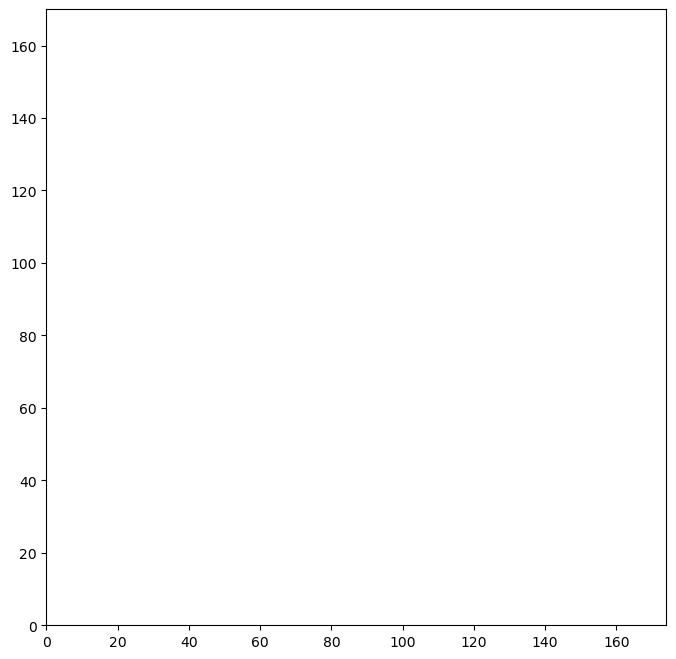

In [29]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 174)
ax.set_ylim(0, 170)

# Initialize empty line and scatter objects
line, = ax.plot([], [], 'b-')  # Line for edges
scat = ax.scatter([], [], c='red', s=50)  # Points

def init():
    line.set_data([], [])
    scat.set_offsets([])
    return line, scat

def animate(frame):
    # Get points for current frame
    points = all_tracked_points[frame] # (17, 2)
    
    # Add first point to end to close the polygon
    points_closed = np.vstack([points, points[0]])
    print(f'points_closed.shape: {points_closed.shape}')
    
    # Update line (edges)
    line.set_data(points_closed[:, 0], points_closed[:, 1])
    
    # Update scatter (points)
    scat.set_offsets(points)
    
    return line, scat

# Create animation
anim = animation.FuncAnimation(fig, animate, init_func=init, frames=frame_cnt, interval=50, blit=True)

plt.show()